# 3D Medical Image Registration Demo

This notebook demonstrates rigid and affine registration workflows for volumetric medical images using SimpleITK and PyTorch.

# Setup

Load the packages used for image IO, visualization, affine transforms, and optimization.

In [ ]:
# Core numerical, image IO, and visualization libraries
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import SimpleITK as sitk
import pandas as pd
import matplotlib.pyplot as plt
import time

# Project helper utilities for notebook visualization and transform conversion.
# In this sanitized demo, these helpers can be replaced by equivalent local utilities.
try:
    from medical_image_utils.sitkview import view_sitk
    from medical_image_utils.transforms import *
except ImportError:
    view_sitk = None


The data directory and image identifiers define the fixed and moving volumes used in the registration example.


In [ ]:
# Root directory for the dataset
root = 'data/medical_registration_demo/data/'

# Fixed and moving images (change these to an arbitrary pair of subject ids)
id_fix, id_mov = 1006, 1012
# id_fix, id_mov = 1009, 1015

# 3D Image Tensors in PyTorch

This section converts 3D medical images between SimpleITK objects and PyTorch tensors. It establishes the tensor shapes needed for later filtering, reslicing, and registration operations.

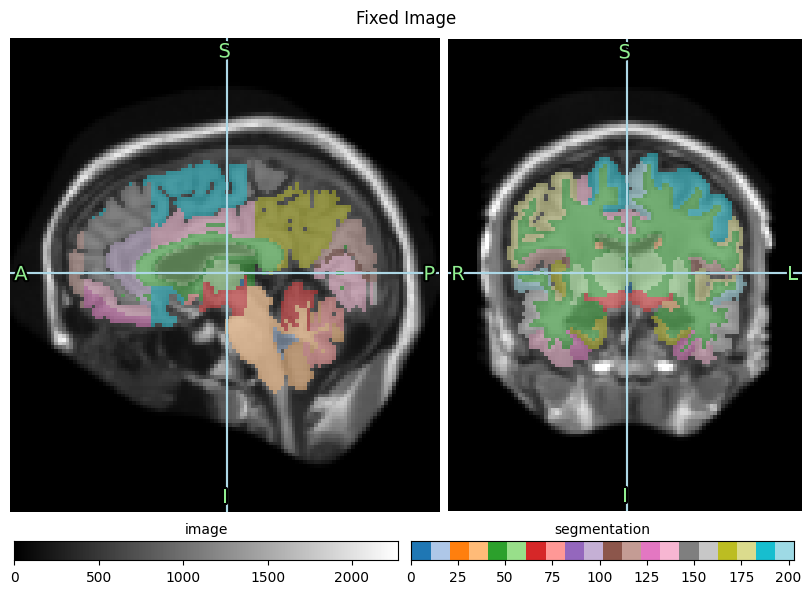

In [ ]:
# Read the fixed image for image processing
img = sitk.ReadImage(f'{root}/images/atlas_2mm_{id_fix}_3.nii.gz')

# Also read the corresponding segmentation image
seg = sitk.ReadImage(f'{root}/images/atlasseg_2mm_{id_fix}_3.nii.gz')

# Show the image and the segmentation
view_sitk(img, seg, cmap=['gray','tab20'], name=['image', 'segmentation'], width=8, title='Fixed Image');

## Part 1A. Mapping 3D Datasets between SimpleITK and PyTorch

The conversion functions map between SimpleITK image geometry and PyTorch tensor layouts. PyTorch 3D routines typically use `[B, C, D, H, W]`, while image registration also requires careful handling of voxel spacing, origin, and physical coordinates.

In [ ]:
# Conversion utilities between PyTorch tensors and SimpleITK images
def my_sitk_to_torch(img, is_warp=False, **kwargs):
    """
    Convert 3D SimpleITK image to PyTorch 5D tensor. Supports scalar images
    and vector (multi-component) images.

    Args:
        img:
            SimpleITK image, 3D scalar or vector image
        is_warp:
            Boolean, indicates whether multi-component images should be treated as
            spatial transformations [1,D,H,W,3] or multi-channel images [1,C,D,H,W]
        dtype, device:
            These parameters will be passed on to torch.tensor()
    Output:
        A torch tensor holding the voxel data
    """
        # Convert SimpleITK image to NumPy array
    array = sitk.GetArrayFromImage(img)

    # Determine the number of components per pixel
    num_components = img.GetNumberOfComponentsPerPixel()

    if is_warp and num_components == 3:
        tensor = torch.tensor(array, **kwargs).permute(3, 0, 1, 2).unsqueeze(0)
    elif num_components > 1:
        tensor = torch.tensor(array, **kwargs).permute(3, 0, 1, 2).unsqueeze(0)
    else:
        tensor = torch.tensor(array, **kwargs).unsqueeze(0).unsqueeze(0)

    return tensor

def my_torch_to_sitk(T, ref, is_warp=False):
    """
    Convert a PyTorch 5D tensor to a 3D SimpleITK image. Supports scalar images
    and vector (multi-component) images.

    Args:
        T:
            A 5-D tensor representing a scalar 3D image [1,1,D,H,W], a multi-channel
            3D image [1,C,D,H,W], or or a 3D spatial transformation [1,D,H,W,3]
        ref:
            Reference 3D image, a SimpleITK image from which the metadata including
            spacing, origin, and direction matrix will be assigned to the output image.
        is_warp:
            Boolean, indicates if the tensor represents a spatial transformation. If so,
            the tensor is expected to have shape [1,D,H,W,3].

    Output:
        A SimpleITK image.
    """
    if is_warp:
        array = T[0].permute(1, 2, 3, 0).cpu().numpy()

    elif T.shape[1] > 1:
        array = T[0].permute(1, 2, 3, 0).cpu().numpy()

    else:
        array = T[0, 0].permute(0, 1, 2).cpu().numpy()

    # Convert NumPy array to SimpleITK image
    img = sitk.GetImageFromArray(array, isVector=is_warp or T.shape[1] > 1)

    # Copy metadata from reference image
    img.CopyInformation(ref)

    return img


The following sanity check validates tensor shape and image metadata conversion.


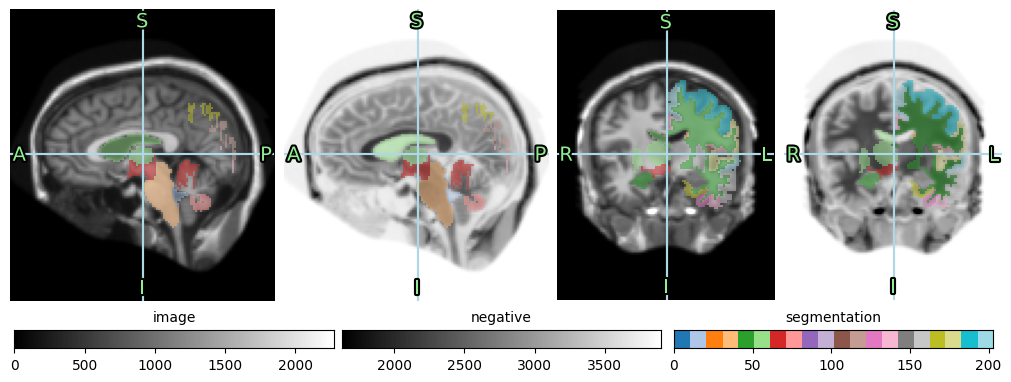

In [ ]:
# Compute the negative image
T_img = my_sitk_to_torch(img, dtype=torch.float32)
T_neg = torch.max(T_img) - T_img
img_neg = my_torch_to_sitk(T_neg, img)

# Remove all odd labels in the segmentation
T_seg = my_sitk_to_torch(seg, dtype=torch.int16)
T_seg_even = torch.where(T_seg % 2 == 1, T_seg, torch.zeros_like(T_seg))
seg_even = my_torch_to_sitk(T_seg_even, img)

# Show the result
view_sitk(img, img_neg, seg_even, layout='tto', cmap=['gray','gray','tab20'],
          name=['image', 'negative', 'segmentation'], width=10);

## Part 1B. PyTorch-Based Region Statistics

The label map is used to compute regional volumes and mean MRI intensity for selected anatomical structures. The calculations are performed with tensor operations rather than voxel-wise Python loops.

In [ ]:
# Define the labels we want to report
labels = {
    31: 'Right Amygdala',
    32: 'Left Amygdala',
    47: 'Right Hippocampus',
    48: 'Left Hippocampus',
    51: 'Right Lateral Ventricle',
    52: 'Left Lateral Ventricle',
}

# Convert MRI and segmentation images to PyTorch tensors
T_img = my_sitk_to_torch(img, dtype=torch.float32).squeeze()
T_seg = my_sitk_to_torch(seg, dtype=torch.int32).squeeze()

# Define target labels
labels = torch.tensor([31, 32, 47, 48, 51, 52], dtype=torch.int32)
label_names = ['Right Amygdala', 'Left Amygdala',
               'Right Hippocampus', 'Left Hippocampus',
               'Right Lateral Ventricle', 'Left Lateral Ventricle']

# Compute voxel volume (mm³)
voxel_volume = 2.0 * 2.0 * 2.0

# Create boolean masks for all target labels
mask = (T_seg.unsqueeze(0) == labels.unsqueeze(1).unsqueeze(2).unsqueeze(3))

# Compute volumes and mean intensities
volumes = mask.sum(dim=[1, 2, 3]) * voxel_volume  # [6]
mean_intensities = (mask * T_img).sum(dim=[1, 2, 3]) / mask.sum(dim=[1, 2, 3])
# Convert to NumPy for visualization
volumes = volumes.cpu().numpy()
mean_intensities = mean_intensities.cpu().numpy()


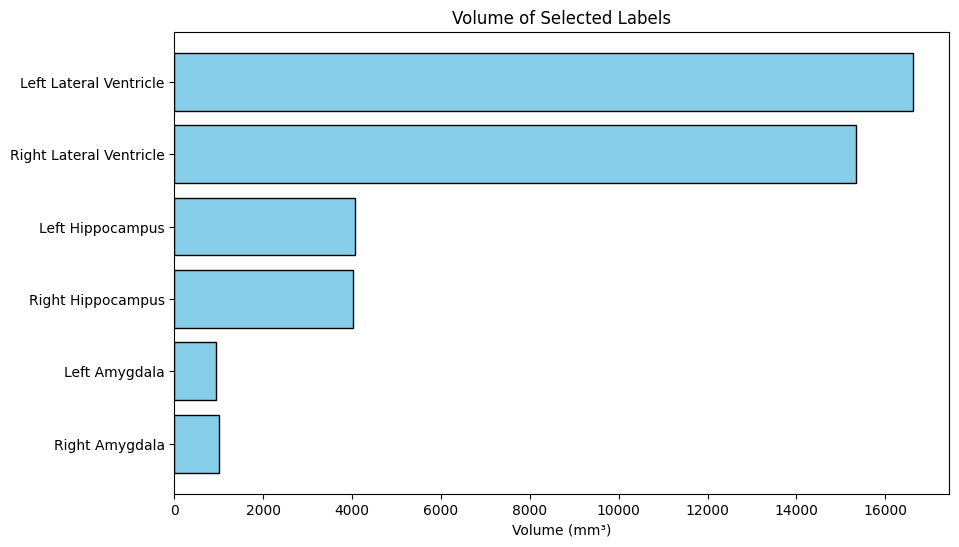

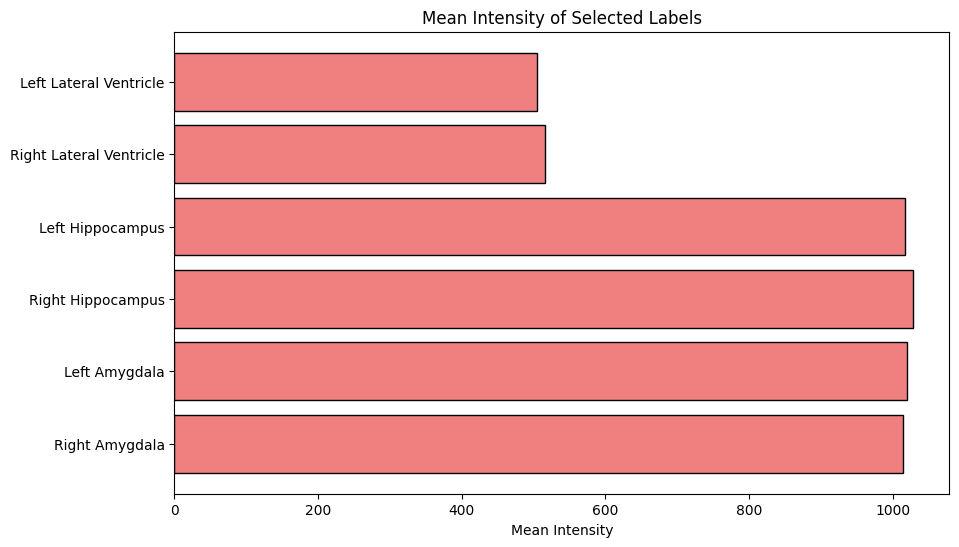

In [ ]:
# Plot volume bar chart
plt.figure(figsize=(10, 6))
plt.barh(label_names, volumes, color='skyblue', edgecolor='black')
plt.xlabel('Volume (mm³)')
plt.title('Volume of Selected Labels')
plt.show()

# Plot mean intensity bar chart
plt.figure(figsize=(10, 6))
plt.barh(label_names, mean_intensities, color='lightcoral', edgecolor='black')
plt.xlabel('Mean Intensity')
plt.title('Mean Intensity of Selected Labels')
plt.show()

In [ ]:
# Create DataFrame
data = {
    'Label': labels.tolist(),
    'Label Name': label_names,
    'Volume (mm³)': volumes,
    'Mean Intensity': mean_intensities
}
df_computed = pd.DataFrame(data)

df_computed

 Label Label Name Volume (mm³) Mean Intensity
0 31 Right Amygdala 992.0 1015.241943
1 32 Left Amygdala 928.0 1020.474121
2 47 Right Hippocampus 4024.0 1027.920532
3 48 Left Hippocampus 4056.0 1017.199219
4 51 Right Lateral Ventricle 15352.0 515.334045
5 52 Left Lateral Ventricle 16616.0 504.800201

In [ ]:
# Create the DataFrame with all required data
data = {
    "Label": [31, 32, 47, 48, 51, 52],
    "Label Name": [
        "Right Amygdala",
        "Left Amygdala",
        "Right Hippocampus",
        "Left Hippocampus",
        "Right Lateral Ventricle",
        "Left Lateral Ventricle",
    ],
    "Volume (mm³)": [992, 928, 4024, 4056, 15350, 16620],
    "Intensity Mean": [1015.2419, 1020.4741, 1027.9205, 1017.1992, 515.3340, 504.8002],
}

# Convert the dictionary to a DataFrame
df_itk = pd.DataFrame(data)

df_itk

 Label Label Name Volume (mm³) Intensity Mean
0 31 Right Amygdala 992 1015.2419
1 32 Left Amygdala 928 1020.4741
2 47 Right Hippocampus 4024 1027.9205
3 48 Left Hippocampus 4056 1017.1992
4 51 Right Lateral Ventricle 15350 515.3340
5 52 Left Lateral Ventricle 16620 504.8002

## Part 1C. Sobel Filtering in PyTorch

A Sobel filter is implemented as a small 3D tensor operation. This provides a compact demonstration of convolution-style image processing before moving into spatial transforms and registration.

(<Figure size 800x553.019 with 3 Axes>, [[<Axes: >], [<Axes: >]])

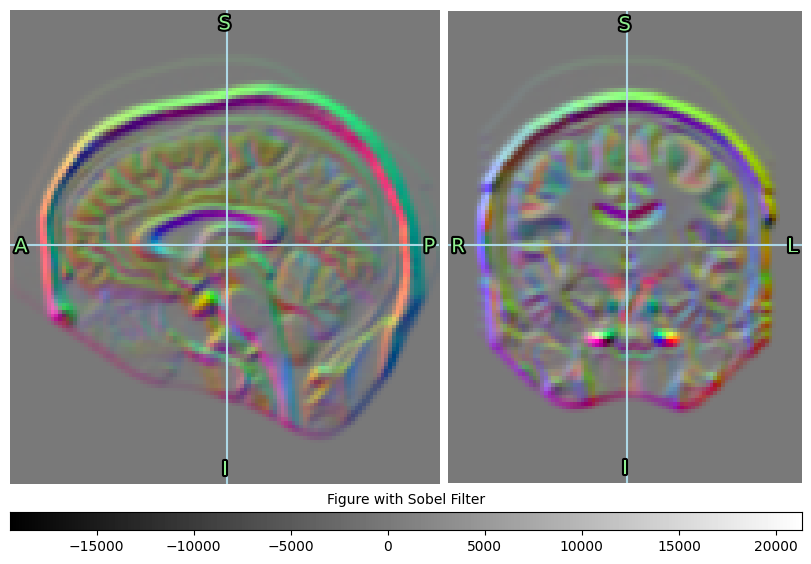

In [ ]:

# Create Sobel kernels using outer products
sobel_1d = torch.tensor([1, 2, 1], dtype=torch.float32)
sobel_x = torch.einsum('i,j,k->ijk', sobel_1d, torch.tensor([1, 0, -1], dtype=torch.float32), sobel_1d)
sobel_y = torch.einsum('i,j,k->ijk', torch.tensor([1, 0, -1], dtype=torch.float32), sobel_1d, sobel_1d)
sobel_z = torch.einsum('i,j,k->ijk', sobel_1d, sobel_1d, torch.tensor([1, 0, -1], dtype=torch.float32))

# Stack filters to form 3D Sobel kernels
sobel_kernels = torch.stack([sobel_x, sobel_y, sobel_z]).unsqueeze(1)

# Convert MRI image to tensor
T_img = my_sitk_to_torch(img, dtype=torch.float32)

# Apply 3D convolution with Sobel kernels
gradients = F.conv3d(T_img, sobel_kernels, padding='same')

# Convert gradients to SimpleITK multi-component image
gradient_sitk = my_torch_to_sitk(gradients, img, is_warp=True)

# Visualize gradients
view_sitk(gradient_sitk, cmap='gray', name='Figure with Sobel Filter')


The tensor conversion, regional statistics, and filtering blocks provide the image-processing foundation used by the registration workflow below.

# Interactive Registration Check

A fixed image, moving image, and segmentation are inspected in ITK-SNAP. Manual, rigid, and affine alignment screenshots are retained as visual references for the later PyTorch implementation.

The screenshots below document fixed/moving image loading and co-registration in ITK-SNAP. The comparison records how manual, rigid, and affine settings affect visual alignment.

## 2.1 Screenshots of Loaded Images

Below are the screenshots demonstrating the images loaded in two different visualization modes: overlay and side-by-side.

Overlay:
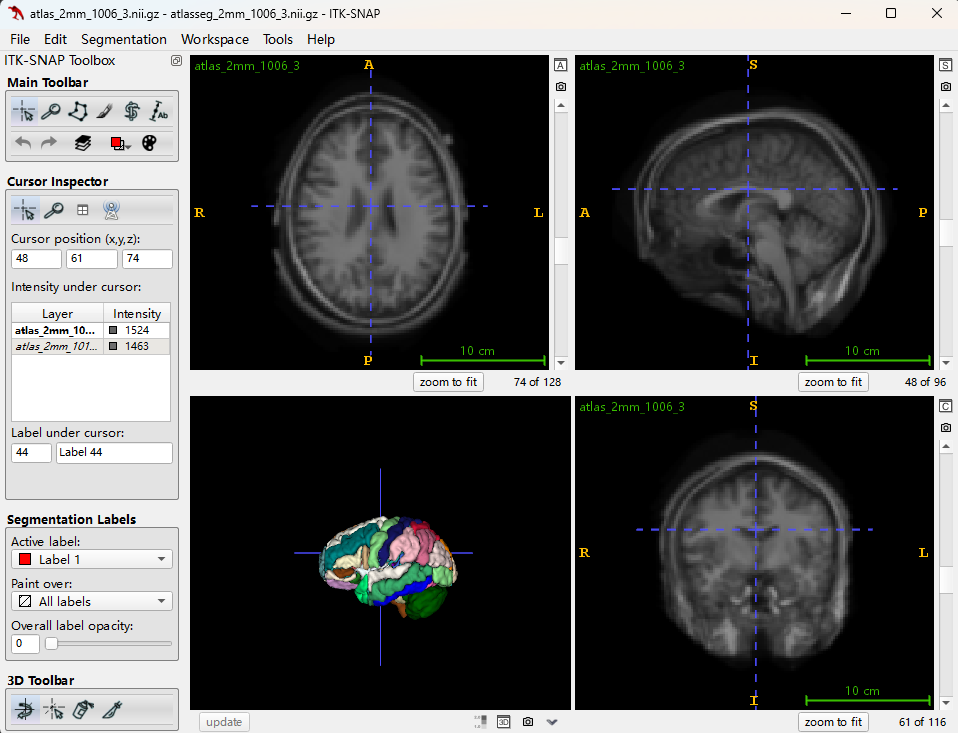

Side-by-side:
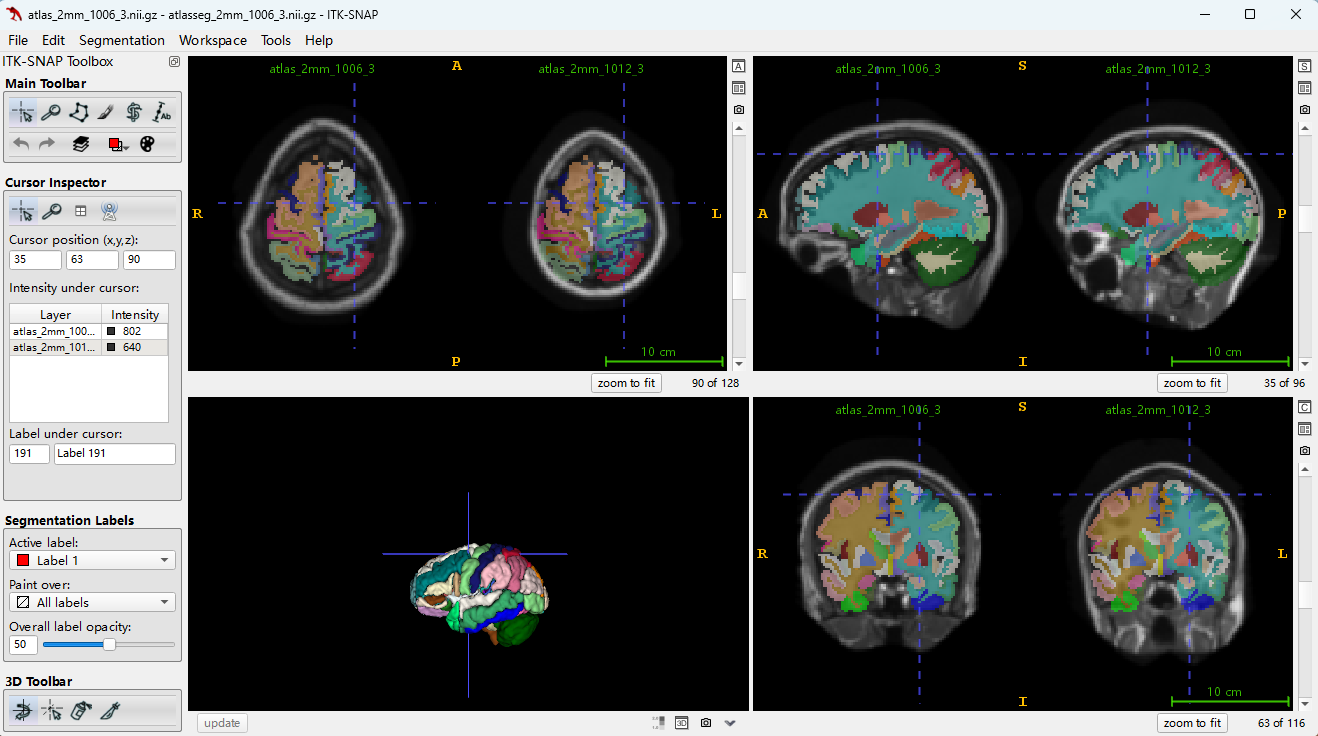

## 2.2 Screenshot of Manually Registered Image
Below is a screenshot of the manually registered moving image aligned with the fixed image in ITK-SNAP.
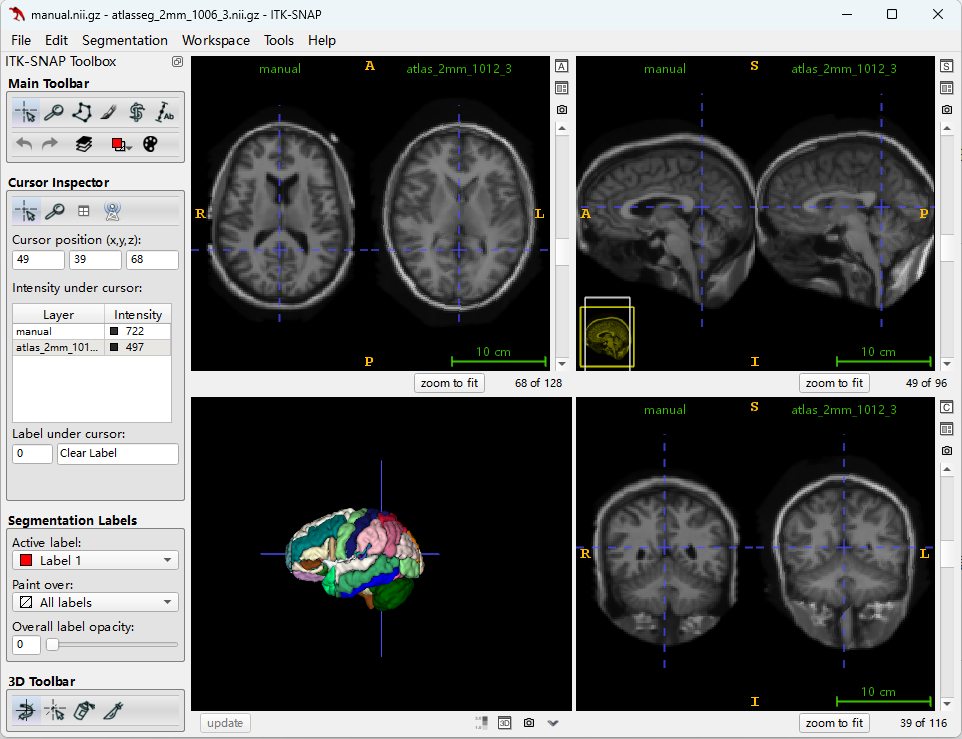

## 2.3 Screenshots of Automatically Registered Images
Below are screenshots of the moving image automatically registered to the fixed image in ITK-SNAP using two different methods: rigid registration and affine registration.

Rigid:
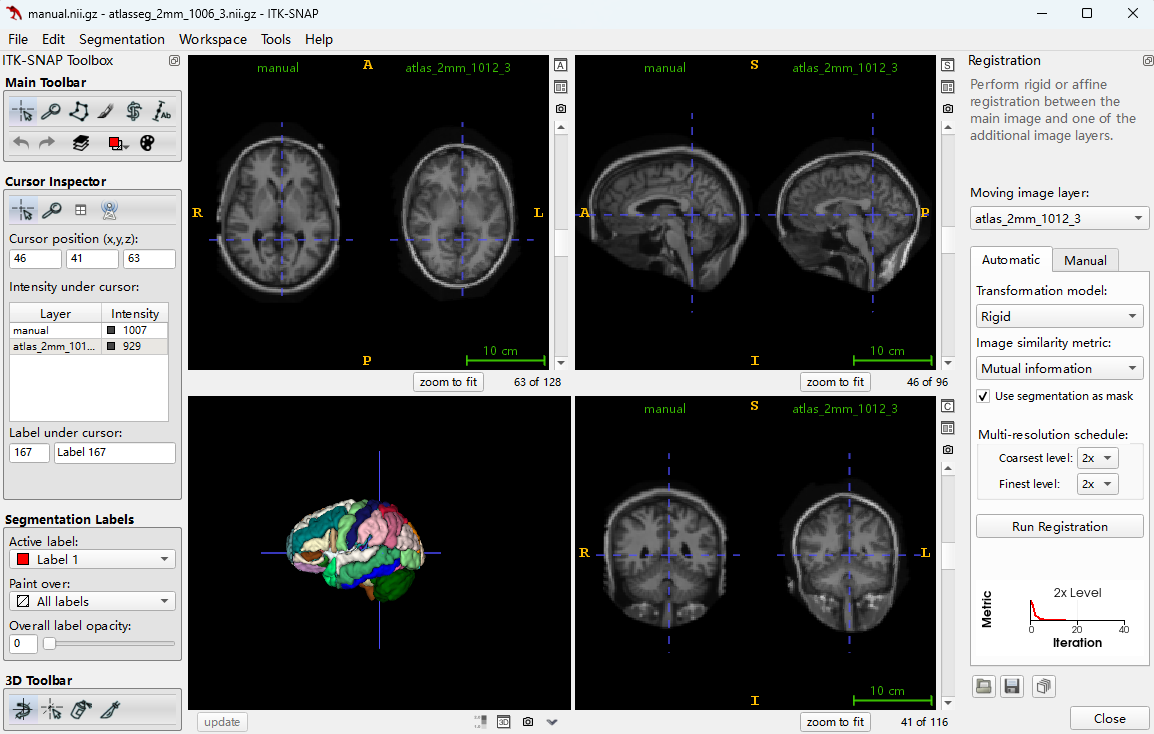

Affine:
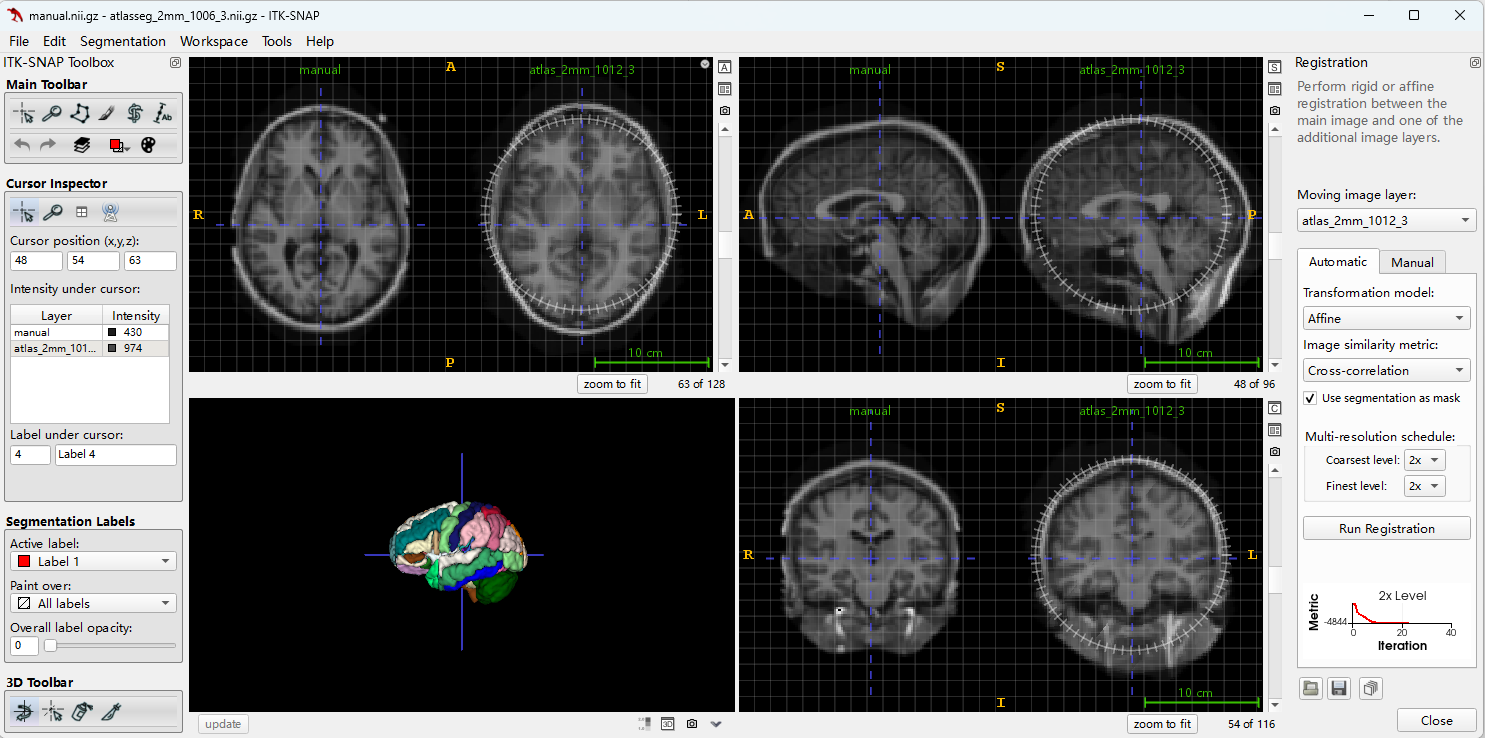

## 2.4 Comparison of Original and Resliced Parameters

Original:

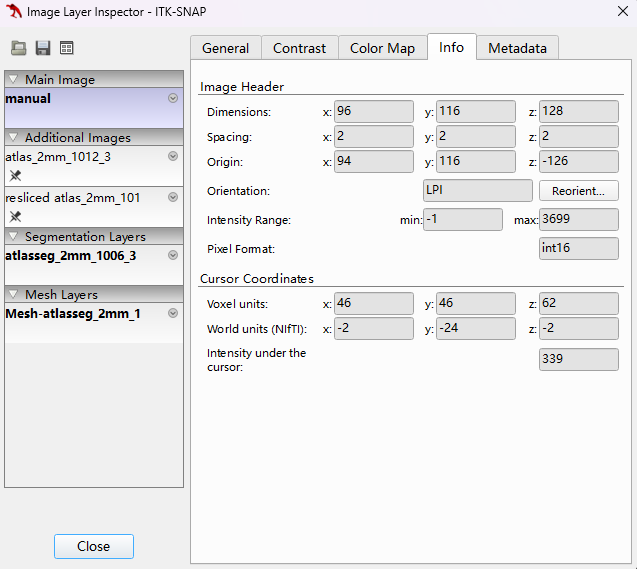

Resliced:

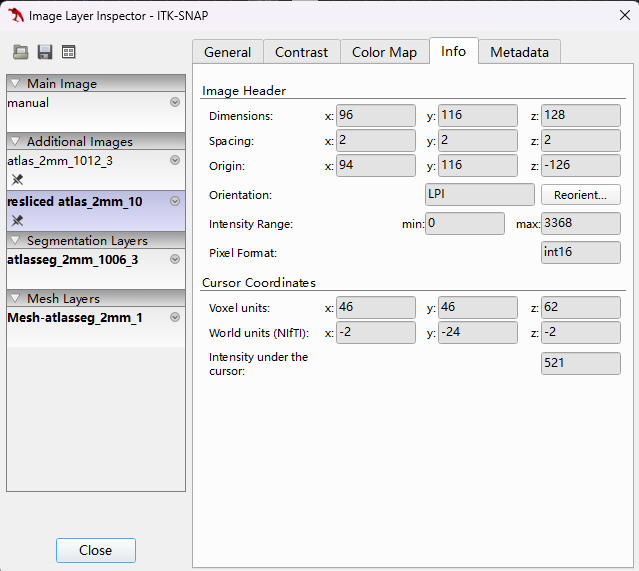

After reslicing, the resliced image matches the fixed image in key spatial metadata, including dimensions [96, 116, 128], voxel spacing [2, 2, 2], origin [94, 116, -126], and orientation LPI. These parameters confirm that the resliced image has been successfully aligned with the fixed image's voxel grid. The only notable difference is the slight variation in intensity range, which is expected due to interpolation or transformation during the reslicing process.

## 2.5 Optimal Automatic Registration Settings
The best registration results were achieved using the following settings: Transformation model set to `Affine`, Image similarity metric as `Cross-correlation`, and enabling the option to `Use segmentation as mask`. For the multiresolution levels, both the Coarsest level and Finest level were configured at `2x`. These settings provided a precise alignment by capturing linear transformations effectively while leveraging segmentation to focus on relevant regions.

## 2.6 Comparison of Automatic and Manual Registration
Automatic registration outperformed manual registration in both convenience and accuracy. The automatic method efficiently captured precise transformations, particularly with the affine model, while requiring minimal user intervention. In contrast, manual registration was time-consuming and prone to less precise adjustments, especially for complex transformations.

# Affine Transformations and Reslicing

PyTorch routines `affine_grid` and `grid_sample` are used to transform the moving image and reslice it into the fixed image space.

The implementation depends on PyTorch normalized coordinates, where image corners map to `[-1, -1, -1]` and `[1, 1, 1]`. This coordinate convention differs from scanner physical space and affects how transforms are interpreted.

In [ ]:
# Function to apply the affine transform in voxel coordinates to a moving image represented
# as a PyTorch tensor
def my_transform_image_pytorch(T_ref, T_mov, A, b,
                               mode='bilinear', padding_mode='zeros'):
    """
    Apply an affine transform to 3D moving image and reslice it into the space of the
    fixed (reference) image.

    Args:
        T_ref:
            Fixed (reference) image, a shape (1,Cf,Df,Hf,Wf) tensor
        T_mov:
            Moving image, represented a shape (1,Cm,Dm,Hm,Wm) tensor
        A:
            Affine transformation matrix in PyTorch coordinate space, a shape (3,3) tensor
        b:
            Translation vector in PyTorch coordinate space, a shape (3) tensor
        mode:
            Interpolation mode, see documentation for `grid_sample`
        padding_mode:
            Padding mode, see documentation for `grid_sample`

    Output:
        Moving image transformed and resliced into reference image space,
        a shape (1,Cm,Df,Hf,Wf) tensor
    """
        # Create affine matrix: [1, 3, 4]
    affine_matrix = torch.cat([A, b.unsqueeze(1)], dim=1).unsqueeze(0)

    # Generate sampling grid
    grid = F.affine_grid(affine_matrix, T_ref.shape, align_corners=True)

    # Compute grid sample
    T_out = F.grid_sample(T_mov, grid, mode=mode, padding_mode=padding_mode, align_corners=True)

    return T_out


The following check reslices the moving image into the fixed image space using an ITK-SNAP affine matrix. The function `map_affine_sitk_to_pytorch` takes care of the messy work of transforming the affine parameters to account for differences between the ITK and PyTorch physical coordinate systems.


Transform parameters in SimpleITK: (0.887724, 0.0424193, 0.0239444, -0.0372304, 0.903752, 0.0287659, -0.0201082, -0.0314321, 0.893624), (2.64199, -1.14215, 3.60602)
Transform parameters in PyTorch: [ 0.887724 0.05125665 -0.03192587 -0.03081137 0.903752 -0.03174168
 0.01508115 0.02848534 0.893624 ], [-0.02938156 0.01010691 0.0272525 ]


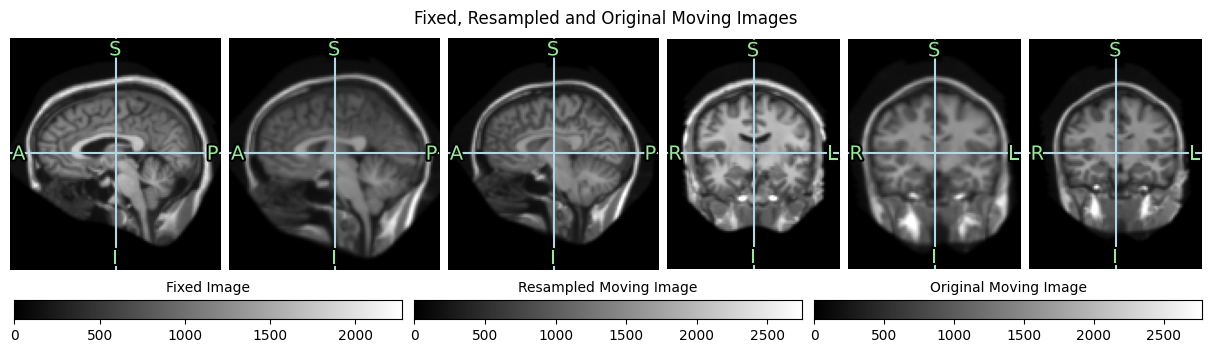

In [ ]:
# Load the fixed and moving images
img_fix = sitk.ReadImage(f'{root}/images/atlas_2mm_{id_fix}_3.nii.gz')
img_mov = sitk.ReadImage(f'{root}/images/atlas_2mm_{id_mov}_3.nii.gz')

# Map to tensors
T_fix, T_mov = (my_sitk_to_torch(x, dtype=torch.float32) for x in (img_fix, img_mov))

# Load the transform into an sitk object (replace the filename with yours)
tran_itk = load_itksnap_transform(f'{root}snap_affine_transform_fx{id_fix}_mv{id_mov}.mat')
print(f'Transform parameters in SimpleITK: {tran_itk.GetMatrix()}, {tran_itk.GetTranslation()}')

# Convert to the format compatible with affine_grid
A, b = map_affine_sitk_to_pytorch(tran_itk, img_fix, img_mov)
T_A, T_b = (torch.tensor(x, dtype=torch.float32) for x in (A,b))
print(f'Transform parameters in PyTorch: {A.flatten()}, {b}')

# Apply transformation
T_resampled = my_transform_image_pytorch(T_fix, T_mov, T_A, T_b)
img_resampled = my_torch_to_sitk(T_resampled, img_fix)

# Visualize the result
view_sitk(img_fix, img_resampled, img_mov,
          name=['Fixed Image','Resampled Moving Image','Original Moving Image'],
          layout='ttt', width=12, cmap='gray', title='Fixed, Resampled and Original Moving Images');

# Rotation Parameterization

This section parameterizes 3D rotations with PyTorch linear algebra operations such as matrix multiplication, inverse, determinant, and trace.

The rotation implementation maps a compact parameter vector to a 3D rotation matrix. The formulas below document the chosen parameterization and the matrix construction used in code.

In [ ]:
def my_rotation_from_vector(x):
    """
    Generate a 3D rotation vector from three parameters.

    Args:
        x:
            A torch tensor of shape (3). It contains the parameters of the rotation.
            The vector direction defines the axis of rotation, and its magnitude defines the rotation angle in radians.
    Output:
        A shape (3,3) tensor holding a rotation matrix corresponding to x
    """
    
    # Compute the rotation angle and axis of rotation
    theta = torch.linalg.norm(x)
    k = x / (theta + 1e-8)

    # Compute skew-symmetric matrix for k
    K = torch.tensor([[0, -k[2], k[1]], [k[2], 0, -k[0]], [-k[1], k[0], 0]], device=x.device, dtype=x.dtype)

    # Compute rotation matrix using Rodrigues' formula
    I = torch.eye(3, device=x.device, dtype=x.dtype)
    R = I + torch.sin(theta) * K + (1 - torch.cos(theta)) * (K @ K)

    return R


The validation cell checks whether the computed matrices satisfy the rotation constraint `R^T R = I`. Values close to zero indicate valid rotation matrices.

In [ ]:
x_check = [ torch.zeros(3) ] + [ torch.rand(3) for i in range(5) ]
for x in x_check:
    R = my_rotation_from_vector(x)
    print(f'Parameters: {x.detach().cpu().numpy()}, |R^T @ R - I| = {torch.det(R.T @ R - torch.eye(3)).item()}')

Parameters: [0. 0. 0.], |R^T @ R - I| = 0.0
Parameters: [0.2220928 0.52108204 0.18344724], |R^T @ R - I| = -2.0515377025276356e-24
Parameters: [0.647655 0.4340698 0.67503077], |R^T @ R - I| = -1.2296440357613991e-23
Parameters: [0.8464559 0.80889434 0.9468601 ], |R^T @ R - I| = 3.3453945111030458e-22
Parameters: [0.33018124 0.27743584 0.6998293 ], |R^T @ R - I| = -3.604240394930122e-24
Parameters: [0.1769548 0.4108709 0.7563902], |R^T @ R - I| = -5.058202314459181e-23


The following plot checks the rotation matrix computation. It plots the trace of the rotation matrix as a function of the three parameters around the point [0,0,0]. At the point [0,0,0], the trace should be equal to 3, and as the parameters are varied, it should reduce smoothly.


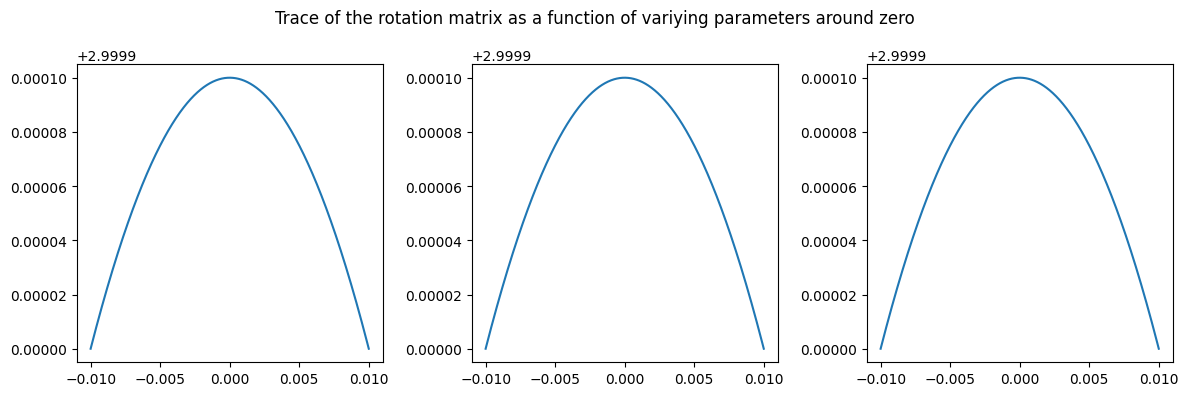

In [ ]:
x0 = torch.zeros(3)
t_range = np.linspace(-0.01, 0.01, 10000)
fx = np.array([ torch.trace(my_rotation_from_vector(torch.tensor([t, 0, 0], dtype=torch.float64))) for t in t_range ])
fy = np.array([ torch.trace(my_rotation_from_vector(torch.tensor([0, t, 0], dtype=torch.float64))) for t in t_range ])
fz = np.array([ torch.trace(my_rotation_from_vector(torch.tensor([0, 0, t], dtype=torch.float64))) for t in t_range ])
fig, ax = plt.subplots(1,3, figsize=(12,4))
ax[0].plot(t_range, fx); ax[0].set_title="X parameter"
ax[1].plot(t_range, fy); ax[1].set_title="Y parameter"
ax[2].plot(t_range, fz); ax[2].set_title="Z parameter"
fig.suptitle('Trace of the rotation matrix as a function of variying parameters around zero');
plt.tight_layout();

Next, use the function to generate a 15 degree ($\pi/12$) rotation of the moving image in the coronal plane (the plane shown on the right in `view_sitk`, with letters R,S,L,I). Apply this rotation to the moving image and visualize like we did above.

(<Figure size 1200x462.264 with 6 Axes>,
 [[<Axes: >, <Axes: >], [<Axes: >, <Axes: >]])

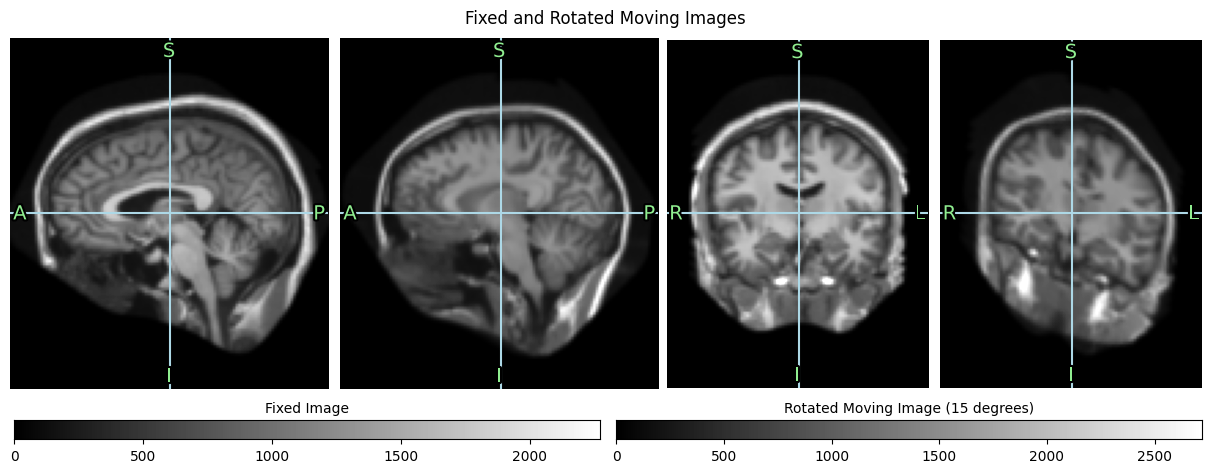

In [ ]:
# Define the rotation angle
theta = np.pi / 12
rotation_vector = torch.tensor([0, theta, 0], dtype=torch.float32)

# Generate the rotation matrix
rotation_matrix = my_rotation_from_vector(rotation_vector)

# Split rotation matrix into A and b
A = rotation_matrix
b = torch.zeros(3, dtype=torch.float32)

# Apply the rotation to the moving image
T_rotated = my_transform_image_pytorch(T_fix, T_mov, A, b)

# Convert the rotated tensor back to SimpleITK image
img_rotated = my_torch_to_sitk(T_rotated, img_fix)

# Visualize the images
view_sitk(img_fix, img_rotated,
          name=['Fixed Image', 'Rotated Moving Image (15 degrees)'],
          layout='tt', width=12, cmap='gray', title='Fixed and Rotated Moving Images')


The visualized transform combines rotation with apparent stretching because PyTorch normalized coordinates and scanner physical coordinates have different aspect ratios. The follow-up correction accounts for voxel spacing so the displayed transform better matches a physical rotation.

The matrix derivation below converts a physical-space rotation into the normalized coordinate system used by PyTorch resampling.

In [ ]:
def map_rotation_to_pytorch_affine(R, img_fix, img_mov):
    """
    Find an affine transformation between a fixed image and a moving image
    in PyTorch coordinates that corresponds to a rotation in physical space.

    Args:
        R:
            Rotation matrix, represented as a shape (3,3) PyTorch tensor
        img_fix:
            Fixed image for this registration, a SimpleITK image
        img_mov:
            Moving image for this registration, a SimpleITK image
    Output:
        A an affine matrix, represented as a shape (3,3) PyTorch tensor
    """
        # Get PyTorch-to-Physical transformation matrices
    Qf, _ = get_pytorch_to_physical_coordinate_transform(img_fix)
    Qm, _ = get_pytorch_to_physical_coordinate_transform(img_mov)

    # Convert to PyTorch tensors
    Qf = torch.tensor(Qf, dtype=torch.float32)
    Qm = torch.tensor(Qm, dtype=torch.float32)

    # Compute affine matrix in PyTorch space
    A = torch.inverse(Qm) @ R @ Qf

    return A


The corrected transform applies a 15-degree rotation in physical image space, producing a visual result that behaves like a true rotation.

(<Figure size 1200x462.264 with 6 Axes>,
 [[<Axes: >, <Axes: >], [<Axes: >, <Axes: >]])

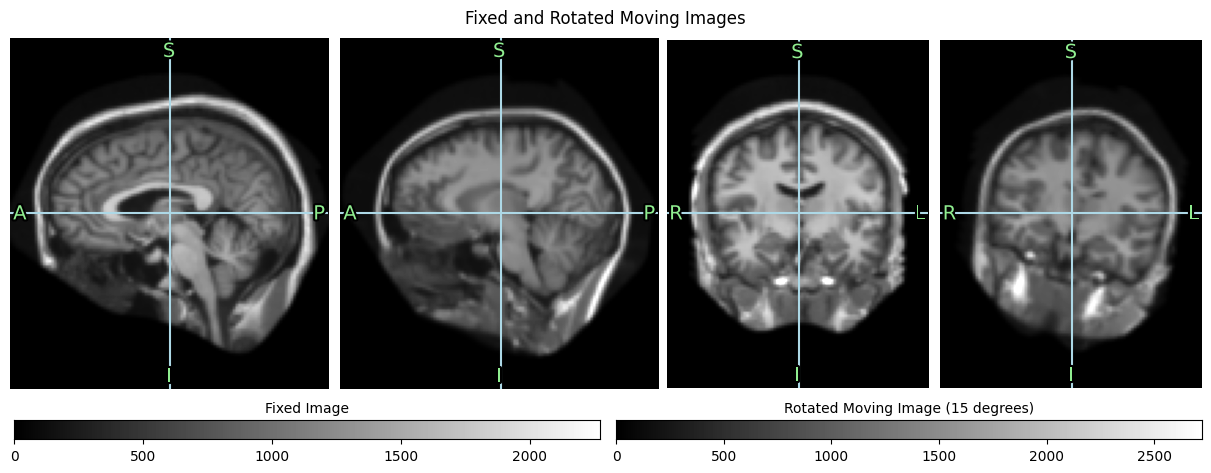

In [ ]:
# Define 15-degree rotation in radians
theta = np.pi / 12

# Create the rotation matrix
R = my_rotation_from_vector(torch.tensor([0, theta, 0], dtype=torch.float32))

# Map to PyTorch affine matrix
A = map_rotation_to_pytorch_affine(R, img_fix, img_mov)

# Apply the transformation to the moving image
T_rotated = my_transform_image_pytorch(T_fix, T_mov, A, torch.zeros(3, dtype=torch.float32))

# Convert the tensor back to SimpleITK image
img_rotated = my_torch_to_sitk(T_rotated, img_fix)

# Visualize the images
view_sitk(img_fix, img_rotated,
          name=['Fixed Image', 'Rotated Moving Image (15 degrees)'],
          layout='tt', width=12, cmap='gray', title='Fixed and Rotated Moving Images')


# Affine Registration in PyTorch

This section implements affine registration by minimizing an SSD-style objective between the fixed image and transformed moving image. The objective is normalized by voxel count and includes intensity centering to keep values numerically stable.

In [ ]:

def my_affine_objective_ssd(T_fix, T_mov, T_A, T_b, z_transform=False):
    """
    Objective function for affine registration using the squared sum of differences (SSD) metric.

    Args:
        T_fix: Fixed (reference) image, a tensor of shape (1,C,Df,Hf,Wf)
        T_mov: Moving image, a tensor of shape (1,C,Dm,Hm,Wm)
        T_A: Affine matrix in PyTorch coordinate space, a tensor of shape (3,3)
        T_b: Translation vector in PyTorch coordinate space, a tensor of shape (3)
        z_transform: Whether to z-transform the image intensities before SSD computation.
    Output:
        Returns a singleton PyTorch tensor storing the value of the SSD metric.
    """
        # Transform the moving image using the affine matrix
    T_resampled = my_transform_image_pytorch(T_fix, T_mov, T_A, T_b)

    # Optionally apply Z-transform to normalize image intensities
    if z_transform:
        T_fix = (T_fix - T_fix.mean()) / (T_fix.std() + 1e-8)
        T_resampled = (T_resampled - T_resampled.mean()) / (T_resampled.std() + 1e-8)

    # Compute the squared sum of differences (SSD)
    ssd = torch.sum((T_fix - T_resampled) ** 2)

    # Normalize SSD by the total number of voxels
    ssd_normalized = ssd / T_fix.numel()

    return ssd_normalized


The next code box calls this function using the identity transform and using the transform you computed in ITK-SNAP

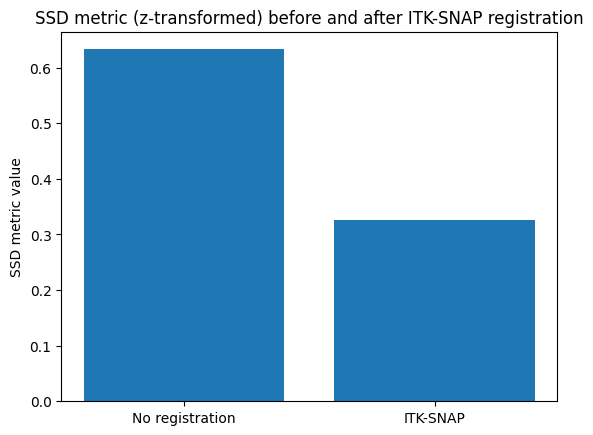

In [ ]:
# Identity transform
T_A_id, T_b_id = (torch.tensor(x, dtype=T_fix.dtype) for x in (np.eye(3), np.zeros(3)))
ssd_id = my_affine_objective_ssd(T_fix, T_mov, T_A_id, T_b_id, z_transform=True)

# Transform from ITK-SNAP
tran_itk = load_itksnap_transform(f'{root}/snap_affine_transform_fx{id_fix}_mv{id_mov}.mat')
T_A_itk, T_b_itk = (torch.tensor(x, dtype=T_fix.dtype) for x in map_affine_sitk_to_pytorch(tran_itk, img_fix, img_mov))
ssd_itk = my_affine_objective_ssd(T_fix, T_mov, T_A_itk, T_b_itk, z_transform=True)

# Compare before and after
plt.bar(['No registration', 'ITK-SNAP'], [ssd_id.item(), ssd_itk.item()]);
plt.title('SSD metric (z-transformed) before and after ITK-SNAP registration');
plt.ylabel('SSD metric value');

Here comes the reason we have been suffering through PyTorch all along! PyTorch lets us compute the partial derivatives of the objective function with respect to $\mathbf{A}$ and $\mathbf{b}$ like this:

In [ ]:
# Create versions of the tensors T_A and T_b that track their partial derivatives
T_A_id_grad, T_b_id_grad = (torch.tensor(x, dtype=T_fix.dtype, requires_grad=True)
                            for x in (np.eye(3), np.zeros(3)))

# Compute the objective function (forward pass)
obj = my_affine_objective_ssd(T_fix, T_mov, T_A_id_grad, T_b_id_grad, z_transform=True)

# Compute the partial derivatives of the objective function with respect to
# elements of T_A_id_grad and T_b_id_grad automatically (backward pass)
obj.backward()

# Print the objective function value and partial derivatives
obj, T_A_id_grad.grad, T_b_id_grad.grad

(tensor(0.6331, grad_fn=<DivBackward0>),
 tensor([[ 1.0643, 0.2142, -0.1445],
 [ 0.2402, -0.1536, 0.2190],
 [-0.2821, 0.2247, 0.5493]]),
 tensor([-2.0024, -0.5888, -0.5040]))

The gradient calculation is repeated for the affine transform estimated in ITK-SNAP, providing a comparison between a neutral initialization and a more aligned transform.

In [ ]:
# Create versions of the tensors T_A and T_b that track their partial derivatives
T_A_itk_grad, T_b_itk_grad = (torch.tensor(x, dtype=T_fix.dtype, requires_grad=True)
                              for x in map_affine_sitk_to_pytorch(tran_itk, img_fix, img_mov))

# Compute the objective function (forward pass)
obj = my_affine_objective_ssd(T_fix, T_mov, T_A_itk_grad, T_b_itk_grad, z_transform=True)

# Compute the partial derivatives of the objective function with respect to
# elements of T_A_id_grad and T_b_id_grad automatically (backward pass)
obj.backward()

# Print the objective function value and partial derivatives
obj, T_A_itk_grad.grad, T_b_itk_grad.grad

(tensor(0.3266, grad_fn=<DivBackward0>),
 tensor([[-0.6380, -0.0710, -0.1046],
 [ 0.0590, -0.5597, 0.0216],
 [-0.1985, -0.2180, -0.8709]]),
 tensor([-0.0936, -0.7493, 0.7232]))

The gradient values indicate how strongly the objective would change under small parameter updates. A better-aligned transform is expected to have smaller gradients, although interpolation, intensity differences, and local minima can prevent values from reaching zero.

## 5A.1 Gradient Magnitude After Initialization
The gradient values in the second cell are smaller compared to the first cell. This is expected because the ITK-SNAP transform aligns the moving image with the fixed image, significantly reducing the misalignment. Consequently, the SSD metric is smaller, and the gradients (which indicate how much the transform parameters need to change) are also smaller.


## 5A.2 Gradient Interpretation
The gradient values in the second cell are not expected to be exactly zero. While the ITK-SNAP transform improves alignment, it is not perfect. The gradients indicate there is still room for further adjustments to reduce the SSD metric. This behavior is consistent with the fact that the registration process can often benefit from fine-tuning.


## 5A.3 Objective Function Check
Yes, the results match expectations. The objective function value decreased from 0.6331 (identity transform) to 0.3266 (ITK-SNAP transform), and the gradients in the second cell are smaller in magnitude than those in the first cell. This reflects the improvement in alignment achieved by the ITK-SNAP transform, while the non-zero gradients suggest potential for further refinement.


## Part 5B. Optimization

The affine objective is optimized with stochastic gradient descent and L-BFGS. Tracking objective values across iterations makes it possible to compare convergence behavior between the two optimizers.

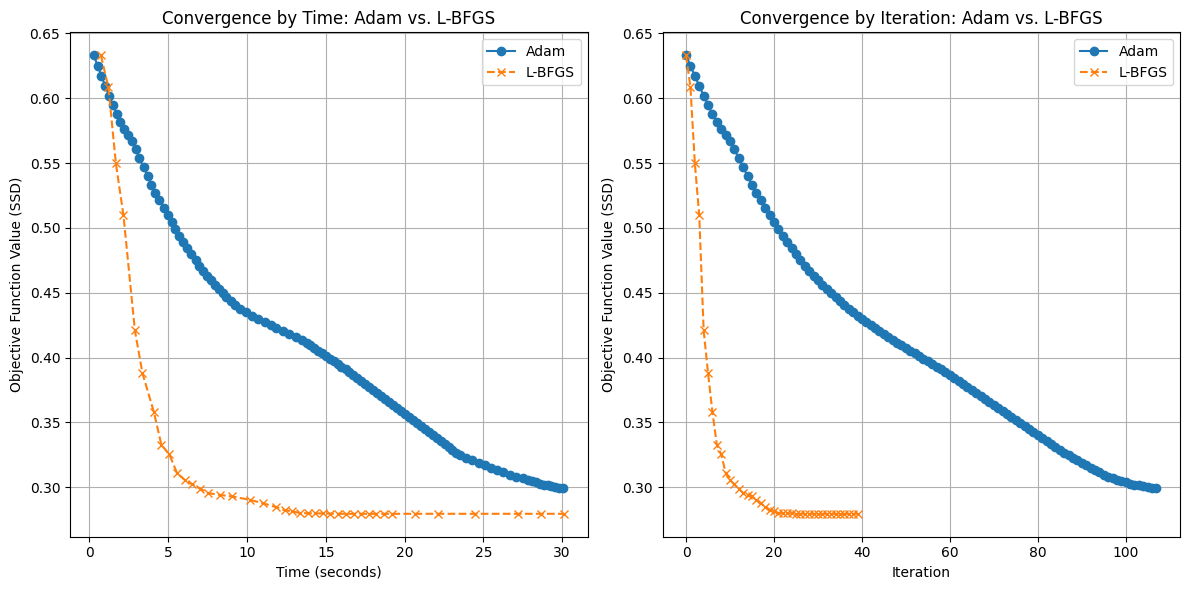

In [ ]:
import torch.optim as optim

# Initialize affine transform parameters
time_limit = 30

# Lists to store history for time and iterations
loss_history_adam = []
loss_history_lbfgs = []
iter_loss_adam = []
iter_loss_lbfgs = []

# Adam Optimizer
T_A_adam = torch.eye(3, requires_grad=True)
T_b_adam = torch.zeros(3, requires_grad=True)
optimizer_adam = optim.Adam([T_A_adam, T_b_adam], lr=1e-3)

start_time = time.time()
iteration_adam = 0
while time.time() - start_time < time_limit:
    optimizer_adam.zero_grad()
    loss = my_affine_objective_ssd(T_fix, T_mov, T_A_adam, T_b_adam, z_transform=True)
    loss.backward()
    optimizer_adam.step()
    current_time = time.time() - start_time
    loss_history_adam.append((current_time, loss.item()))
    iter_loss_adam.append((iteration_adam, loss.item()))
    iteration_adam += 1

# L-BFGS Optimizer
T_A_lbfgs = torch.eye(3, requires_grad=True)
T_b_lbfgs = torch.zeros(3, requires_grad=True)
optimizer_lbfgs = optim.LBFGS([T_A_lbfgs, T_b_lbfgs], max_iter=1, line_search_fn="strong_wolfe", tolerance_grad=1e-6)

start_time = time.time()
iteration_lbfgs = 0
while time.time() - start_time < time_limit:
    def lbfgs_closure():
        optimizer_lbfgs.zero_grad()
        loss = my_affine_objective_ssd(T_fix, T_mov, T_A_lbfgs, T_b_lbfgs, z_transform=True)
        loss.backward()
        return loss

    loss = optimizer_lbfgs.step(lbfgs_closure)
    current_time = time.time() - start_time
    loss_history_lbfgs.append((current_time, loss.item()))
    iter_loss_lbfgs.append((iteration_lbfgs, loss.item()))
    iteration_lbfgs += 1

# Extract time and loss values for plotting
times_adam, losses_adam = zip(*loss_history_adam)
times_lbfgs, losses_lbfgs = zip(*loss_history_lbfgs)

iters_adam, iter_losses_adam = zip(*iter_loss_adam)
iters_lbfgs, iter_losses_lbfgs = zip(*iter_loss_lbfgs)

# Plotting both graphs
plt.figure(figsize=(12, 6))

# Time-based convergence
plt.subplot(1, 2, 1)
plt.plot(times_adam, losses_adam, label="Adam", linestyle='-', marker='o')
plt.plot(times_lbfgs, losses_lbfgs, label="L-BFGS", linestyle='--', marker='x')
plt.xlabel("Time (seconds)")
plt.ylabel("Objective Function Value (SSD)")
plt.title("Convergence by Time: Adam vs. L-BFGS")
plt.legend()
plt.grid(True)

# Iteration-based convergence
plt.subplot(1, 2, 2)
plt.plot(iters_adam, iter_losses_adam, label="Adam", linestyle='-', marker='o')
plt.plot(iters_lbfgs, iter_losses_lbfgs, label="L-BFGS", linestyle='--', marker='x')
plt.xlabel("Iteration")
plt.ylabel("Objective Function Value (SSD)")
plt.title("Convergence by Iteration: Adam vs. L-BFGS")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


Lastly use the optimal parameters to reslice the moving image and plot the result of the registration using `view_sitk`.

(<Figure size 800x341.509 with 6 Axes>,
 [[<Axes: >, <Axes: >], [<Axes: >, <Axes: >]])

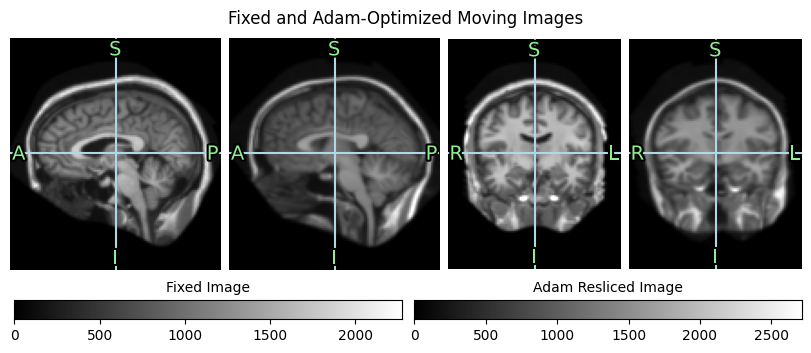

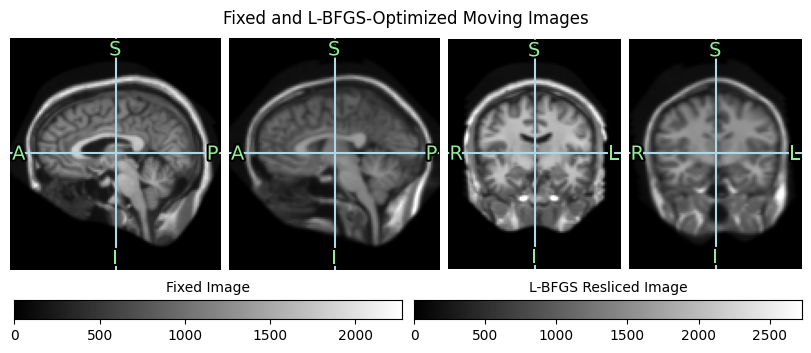

In [ ]:
# Reslice moving image using Adam's result
img_resliced_adam = my_torch_to_sitk(my_transform_image_pytorch(T_fix, T_mov, T_A_adam.detach(), T_b_adam.detach()), ref=img_fix)

# Reslice moving image using L-BFGS's result
img_resliced_lbfgs = my_torch_to_sitk(my_transform_image_pytorch(T_fix, T_mov, T_A_lbfgs.detach(), T_b_lbfgs.detach()), ref=img_fix)

# Visualize Adam's result
view_sitk(img_fix, img_resliced_adam, title='Fixed and Adam-Optimized Moving Images', name=['Fixed Image', 'Adam Resliced Image'], layout='tt')

# Visualize L-BFGS's result
view_sitk(img_fix, img_resliced_lbfgs, title='Fixed and L-BFGS-Optimized Moving Images', name=['Fixed Image', 'L-BFGS Resliced Image'], layout='tt')


# Extended Registration Experiments

The extension compares registration variants across a small set of image pairs. The focus is objective convergence, visual alignment quality, and the tradeoff between affine flexibility and rigid-transform stability.

## 6.1 Implementation of Rigid Registration

In [ ]:
from tqdm import tqdm

def rigid_registration(T_fix, T_mov, max_iters=100):
    """
    Perform rigid registration using L-BFGS optimizer and record objective function values.

    Args:
        T_fix: Fixed image, a tensor of shape (1, C, Df, Hf, Wf).
        T_mov: Moving image, a tensor of shape (1, C, Dm, Hm, Wm).
        max_iters: Maximum number of iterations for optimization.

    Returns:
        R: Optimized rotation matrix of shape (3, 3).
        b: Optimized translation vector of shape (3).
        loss_history: List of SSD values for each iteration.
    """
    # Initialize rotation vector and translation vector
    rotation_vector = torch.zeros(3, requires_grad=True)
    b = torch.zeros(3, requires_grad=True)

    # Define L-BFGS optimizer
    optimizer = torch.optim.LBFGS([rotation_vector, b], max_iter=1, line_search_fn="strong_wolfe", tolerance_grad=1e-6)
    loss_history = []

    # Optimization loop
    for _ in tqdm(range(max_iters)):
        def closure():
            optimizer.zero_grad()
            R = my_rotation_from_vector(rotation_vector)
            loss = my_affine_objective_ssd(T_fix, T_mov, R, b, z_transform=True)
            loss.backward()
            return loss

        # Perform one optimization step and record loss
        loss = optimizer.step(closure)
        loss_history.append(loss.item())

    # Return optimized rotation matrix, translation vector, and loss history
    return my_rotation_from_vector(rotation_vector).detach(), b.detach(), loss_history

In [ ]:
# Perform rigid registration
R_rigid, b_rigid, loss_history_rigid = rigid_registration(T_fix, T_mov, max_iters=30)

100%|██████████| 30/30 [00:09<00:00, 3.03it/s]


## 6.2 Implementation of Affine Registration

In [ ]:
# Perform affine registration using L-BFGS
T_A_init = torch.eye(3, requires_grad=True)
T_b_init = torch.zeros(3, requires_grad=True)

optimizer = torch.optim.LBFGS([T_A_init, T_b_init], max_iter=1, line_search_fn="strong_wolfe")
loss_history_affine = []

for _ in tqdm(range(30)):
    def closure():
        optimizer.zero_grad()
        loss = my_affine_objective_ssd(T_fix, T_mov, T_A_init, T_b_init, z_transform=True)
        loss.backward()
        return loss

    loss = optimizer.step(closure)
    loss_history_affine.append(loss.item())

100%|██████████| 30/30 [00:17<00:00, 1.76it/s]


## 6.3 Comparison of Rigid and Affine Registration

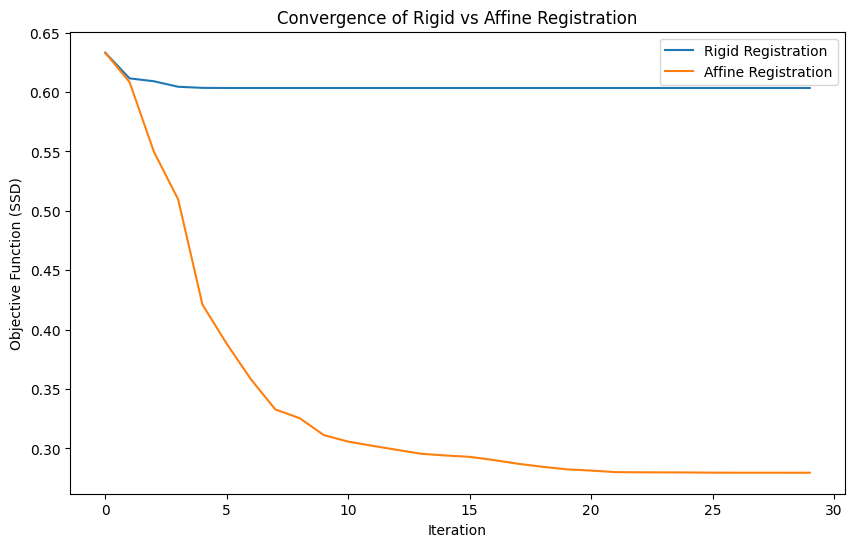

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history_rigid, label='Rigid Registration')
plt.plot(loss_history_affine, label='Affine Registration')
plt.xlabel('Iteration')
plt.ylabel('Objective Function (SSD)')
plt.title('Convergence of Rigid vs Affine Registration')
plt.legend()
plt.show()

The results demonstrate clear differences between rigid and affine registration. The rigid registration curve flattens quickly, indicating that the optimizer converges to a local minimum early on due to the limited degrees of freedom (rotation and translation). In contrast, the affine registration curve exhibits a steep descent and achieves a significantly lower final SSD value, reflecting its ability to capture more complex transformations such as scaling and shearing. This aligns with expectations, as affine registration offers greater flexibility in aligning the images, while rigid registration is constrained to simpler transformations.

(<Figure size 800x341.509 with 6 Axes>,
 [[<Axes: >, <Axes: >], [<Axes: >, <Axes: >]])

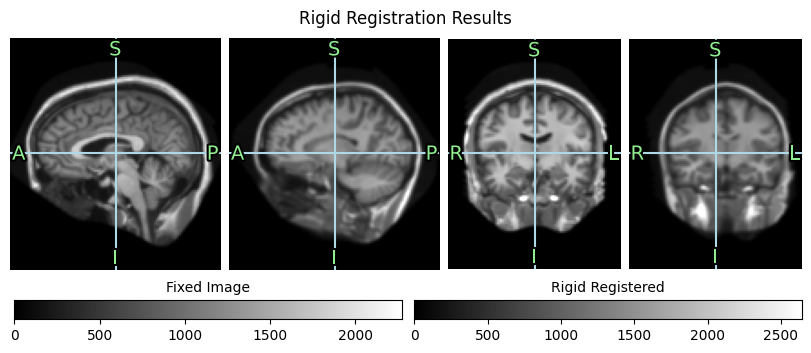

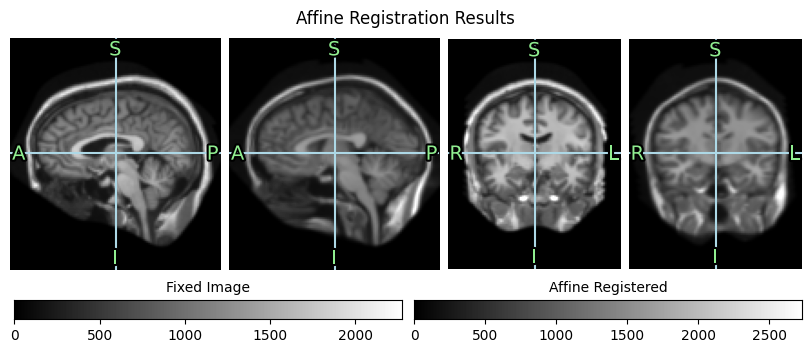

In [ ]:
# Visualize registration results
T_rigid_aligned = my_transform_image_pytorch(T_fix, T_mov, R_rigid, b_rigid)
T_affine_aligned = my_transform_image_pytorch(T_fix, T_mov, T_A_init.detach(), T_b_init.detach())

view_sitk(img_fix, my_torch_to_sitk(T_rigid_aligned, img_fix),
          name=['Fixed Image', 'Rigid Registered'], layout='tt', title='Rigid Registration Results')

view_sitk(img_fix, my_torch_to_sitk(T_affine_aligned, img_fix),
          name=['Fixed Image', 'Affine Registered'], layout='tt', title='Affine Registration Results')

The comparison between the rigid and affine registration results shows that while rigid registration aligns the fixed and moving images well in terms of translation and rotation, affine registration provides better overall alignment by also capturing scaling and shearing transformations. This is particularly evident in regions where anatomical features appear slightly distorted in the rigidly registered image but are more accurately aligned in the affinely registered image, ensuring improved spatial correspondence between the fixed and moving images.

## 6.4 Implementation of Combined Rigid and Affine Registration

In [ ]:
# Perform rigid registration
print("Performing Rigid Registration...")
R_rigid, b_rigid, loss_history_rigid = rigid_registration(T_fix, T_mov, max_iters=15)

# Initialize affine registration using rigid registration results
print("Performing Affine Registration Initialized by Rigid Results...")
T_A_combined = R_rigid.clone().detach().requires_grad_(True)
T_b_combined = b_rigid.clone().detach().requires_grad_(True)

optimizer_combined = torch.optim.LBFGS(
    [T_A_combined, T_b_combined],
    max_iter=1,
    line_search_fn="strong_wolfe"
)

loss_history_combined = []

for _ in tqdm(range(15)):
    def closure_combined():
        optimizer_combined.zero_grad()
        loss = my_affine_objective_ssd(T_fix, T_mov, T_A_combined, T_b_combined, z_transform=True)
        loss.backward()
        loss_history_combined.append(loss.item())
        return loss

    optimizer_combined.step(closure_combined)


Performing Rigid Registration...


100%|██████████| 15/15 [00:06<00:00, 2.34it/s]


Performing Affine Registration Initialized by Rigid Results...


100%|██████████| 15/15 [00:07<00:00, 2.01it/s]


## 6.5 Comparison of Affine and Combined Registration

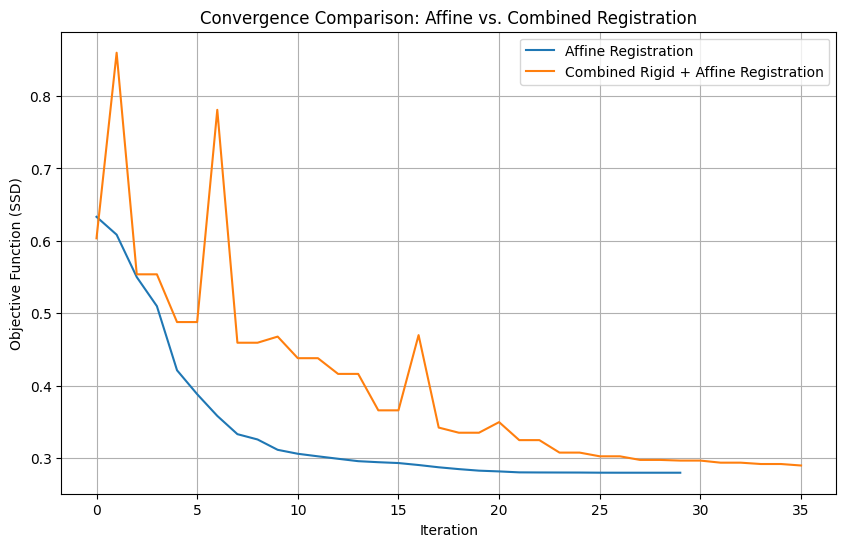

In [ ]:
# Plot the convergence curves for affine and combined rigid+affine registration
plt.figure(figsize=(10, 6))
plt.plot(range(len(loss_history_affine)), loss_history_affine, label="Affine Registration")
plt.plot(range(len(loss_history_combined)), loss_history_combined, label="Combined Rigid + Affine Registration")
plt.xlabel("Iteration")
plt.ylabel("Objective Function (SSD)")
plt.title("Convergence Comparison: Affine vs. Combined Registration")
plt.legend()
plt.grid(True)
plt.show()

The convergence curves show that the affine registration achieves a smoother and more consistent decrease in the objective function (SSD) compared to the combined rigid+affine approach. While the combined method starts with larger oscillations, likely due to the rigid initialization, it eventually converges to a similar SSD value as the affine-only approach. This suggests that the combined approach can benefit from rigid initialization but may require better parameter tuning to avoid instability during early iterations.

(<Figure size 800x341.509 with 6 Axes>,
 [[<Axes: >, <Axes: >], [<Axes: >, <Axes: >]])

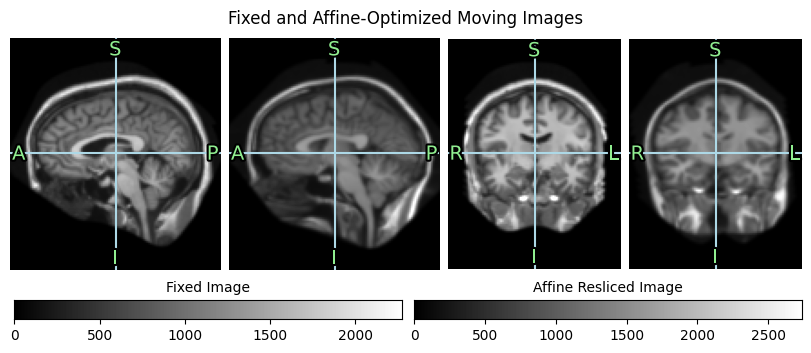

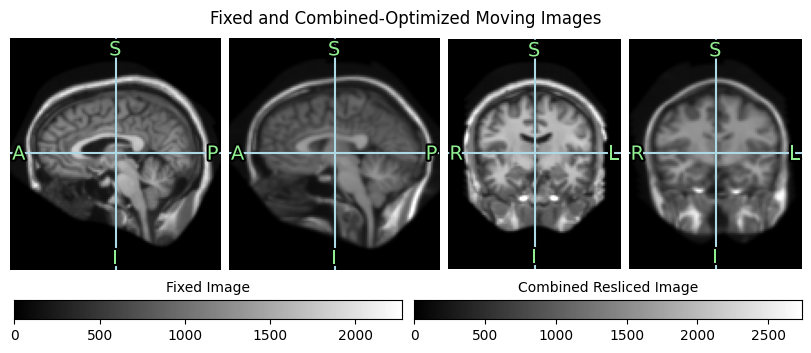

In [ ]:
# Reslice moving image using Affine registration result
img_resliced_affine = my_torch_to_sitk(my_transform_image_pytorch(T_fix, T_mov, T_A_init.detach(), T_b_init.detach()), ref=img_fix)

# Reslice moving image using Combined registration result
img_resliced_combined = my_torch_to_sitk(my_transform_image_pytorch(T_fix, T_mov, T_A_combined.detach(), T_b_combined.detach()), ref=img_fix)

# Visualize Affine registration result
view_sitk(img_fix, img_resliced_affine, title='Fixed and Affine-Optimized Moving Images', name=['Fixed Image', 'Affine Resliced Image'], layout='tt')

# Visualize Combined registration result
view_sitk(img_fix, img_resliced_combined, title='Fixed and Combined-Optimized Moving Images', name=['Fixed Image', 'Combined Resliced Image'], layout='tt')

The affine-optimized image demonstrates a slightly more precise alignment between the fixed and moving images, especially in regions of anatomical overlap, compared to the combined rigid + affine approach. While the combined approach provides good initial alignment and compensates for rotation effectively, the affine-only registration refines the transformation, yielding better overall intensity consistency and structural correspondence.

## 6.6 Comprehensive Evaluation of Rigid, Affine, and Combined Registration Across 10 Image Pairs

In [ ]:
from tqdm import tqdm

def perform_registration_and_visualization(id_fix, id_mov, root, max_iters_rigid=20, max_iters_affine=20):
    """
    Perform Rigid, Affine, and Combined Registration, and visualize results.

    Args:
        id_fix (int): ID of the fixed image.
        id_mov (int): ID of the moving image.
        root (str): Root directory containing the images.
        max_iters_rigid (int): Maximum iterations for rigid registration.
        max_iters_affine (int): Maximum iterations for affine registration.
    """
    import SimpleITK as sitk

    # Step 1: Load the fixed and moving images
    img_fix = sitk.ReadImage(f'{root}/images/atlas_2mm_{id_fix}_3.nii.gz')
    img_mov = sitk.ReadImage(f'{root}/images/atlas_2mm_{id_mov}_3.nii.gz')

    # Step 2: Convert images to PyTorch tensors
    T_fix = my_sitk_to_torch(img_fix, dtype=torch.float32)
    T_mov = my_sitk_to_torch(img_mov, dtype=torch.float32)

    # Step 3: Perform Rigid Registration (20 iterations)
    print("Performing Rigid Registration...")
    R_rigid, b_rigid, loss_history_rigid = rigid_registration(T_fix, T_mov, max_iters=max_iters_rigid)
    img_resliced_rigid = my_torch_to_sitk(
        my_transform_image_pytorch(T_fix, T_mov, R_rigid, b_rigid), ref=img_fix
    )

    # Step 4: Perform Affine Registration (20 iterations)
    print("Performing Affine Registration...")
    T_A_init = torch.eye(3, requires_grad=True)
    T_b_init = torch.zeros(3, requires_grad=True)
    optimizer = torch.optim.LBFGS([T_A_init, T_b_init], max_iter=1, line_search_fn="strong_wolfe")
    loss_history_affine = []
    for _ in tqdm(range(max_iters_affine)):
        def closure():
            optimizer.zero_grad()
            loss = my_affine_objective_ssd(T_fix, T_mov, T_A_init, T_b_init, z_transform=True)
            loss.backward()
            loss_history_affine.append(loss.item())
            return loss
        optimizer.step(closure)
    img_resliced_affine = my_torch_to_sitk(
        my_transform_image_pytorch(T_fix, T_mov, T_A_init.detach(), T_b_init.detach()), ref=img_fix
    )

    # Step 5: Perform Combined Registration (10 Rigid + 10 Affine iterations)
    print("Performing Combined Registration...")
    T_A_combined = R_rigid.clone().detach().requires_grad_(True)
    T_b_combined = b_rigid.clone().detach().requires_grad_(True)
    optimizer_combined = torch.optim.LBFGS([T_A_combined, T_b_combined], max_iter=1, line_search_fn="strong_wolfe")
    loss_history_combined = []
    for _ in tqdm(range(max_iters_rigid // 2)):  # First 10 iterations for rigid
        def closure_combined_rigid():
            optimizer_combined.zero_grad()
            loss = my_affine_objective_ssd(T_fix, T_mov, T_A_combined, T_b_combined, z_transform=True)
            loss.backward()
            loss_history_combined.append(loss.item())
            return loss
        optimizer_combined.step(closure_combined_rigid)

    for _ in tqdm(range(max_iters_affine // 2)):  # Next 10 iterations for affine
        def closure_combined_affine():
            optimizer_combined.zero_grad()
            loss = my_affine_objective_ssd(T_fix, T_mov, T_A_combined, T_b_combined, z_transform=True)
            loss.backward()
            loss_history_combined.append(loss.item())
            return loss
        optimizer_combined.step(closure_combined_affine)

    img_resliced_combined = my_torch_to_sitk(
        my_transform_image_pytorch(T_fix, T_mov, T_A_combined.detach(), T_b_combined.detach()), ref=img_fix
    )

    # Step 6: Visualize Results
    print("Visualizing Results...")
    view_sitk(
        img_fix, img_resliced_rigid,
        title=f'Rigid Registration Results for Id {id_fix} and {id_mov}',
        name=['Fixed Image', 'Rigid Resliced Image'],
        layout='tt'
    )
    view_sitk(
        img_fix, img_resliced_affine,
        title=f'Affine Registration Results for Id {id_fix} and {id_mov}',
        name=['Fixed Image', 'Affine Resliced Image'],
        layout='tt'
    )
    view_sitk(
        img_fix, img_resliced_combined,
        title=f'Combined Registration Results for Id {id_fix} and {id_mov}',
        name=['Fixed Image', 'Combined Resliced Image'],
        layout='tt'
    )

In [ ]:
import random

# List of IDs extracted from the file names
ids = [1000, 1001, 1002, 1006, 1007, 1008, 1009, 1010, 1011, 1012, 1013, 1014, 1015, 1017, 1036]

# Randomly shuffle the IDs
random.shuffle(ids)

# Generate 10 unique pairs of IDs (without repeating)
pairs = [(ids[i], ids[i + 1]) for i in range(0, min(len(ids) - 1, 10))]

print(pairs)

[(1007, 1008), (1008, 1014), (1014, 1012), (1012, 1017), (1017, 1006), (1006, 1001), (1001, 1010), (1010, 1000), (1000, 1002), (1002, 1011)]


In [ ]:
root = 'data/medical_registration_demo/data/'

# Loop through each pair and perform registration
for i, (id_fix, id_mov) in enumerate(pairs, start=1):
    print('---------------------------------------------------------------')
    print(f"Processing Pair {i}: Fixed Image Id {id_fix}, Moving Image Id {id_mov}")
    perform_registration_and_visualization(id_fix, id_mov, root)

After analyzing the results of the 10 image pairs across rigid, affine, and combined registrations, no cases of complete misregistration were observed in either rigid or affine registration. However, rigid registration provided more consistent global alignment, while affine registration occasionally introduced slight distortions in some local regions, particularly when the initial misalignment was substantial. Overall, there was no scenario where rigid registration succeeded and affine completely failed; instead, combined registration consistently provided the most refined and accurate results.

In [ ]:
!jupyter nbconvert --to html medical_image_registration_demo.ipynb

Setup log omitted.
Setup log omitted.
Setup log omitted.
